# Normal Distribution <hr style="border:2.5px solid rgb(242, 218, 161)"></hr>

<b>John Clark Dojoles</b>
<br>Computer Engineer

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"dataset\transformer-voltage.csv",
                 index_col='Sample',
                 delimiter=',')
df

,Voltage
Sample,
1,117.0
2,118.3
3,119.5
4,119.5
5,119.6
6,119.6
7,119.7
8,119.7
9,119.7


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 1 to 30
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  30 non-null     float64
dtypes: float64(1)
memory usage: 372.0 bytes


In [5]:
df.describe()

,Voltage
count,30.000000
mean,120.290000
std,1.243285
min,117.000000
25%,119.700000
50%,120.100000
75%,120.500000
max,123.800000


In [6]:
alpha = 0.01
z_critical = stats.norm.ppf(1-alpha/2)
z_critical

np.float64(2.5758293035489004)

In [7]:
pop_std = 5

ci_lower, ci_upper = stats.norm.interval(
    confidence = 0.95,
    loc = df['Voltage'].mean(),
    scale = pop_std/np.sqrt(df['Voltage'].count())
)

print(f"Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

Confidence Interval: [118.50, 122.08]


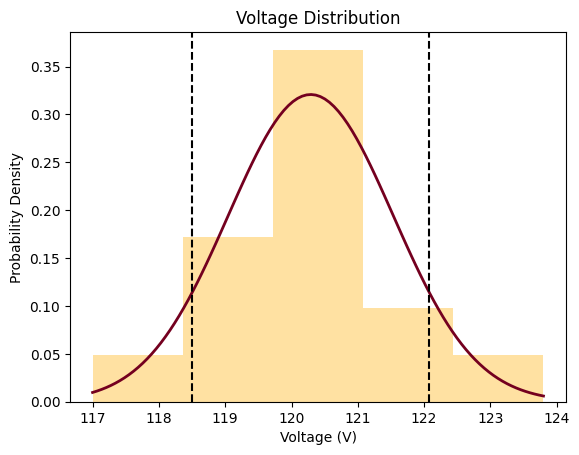

In [8]:
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

x = np.linspace(x_min, x_max,100)
p = stats.norm.pdf(x,mean,std)
plt.plot(x,p,
         linewidth=2,
         color="#74001F")

plt.hist(df['Voltage'],
         bins=5,
         density=True,
         alpha=0.8,
         color="#FFDA8B")

plt.title('Voltage Distribution')
plt.ylabel('Probability Density')
plt.xlabel('Voltage (V)')

plt.axvline(x=ci_lower,
            color='black',
            linestyle='--')
plt.axvline(x=ci_upper,
            color='black',
            linestyle='--')

plt.show()